In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dmatis/s/ssd/rl-optimization/turnus


In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [483]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

class PolicyNetwork(torch.nn.Module):
    def __init__(self, state_size, node_count):
        super().__init__()
        self.state_size = state_size
        self.node_count = node_count

        self.conv1 = GATConv(state_size, 32)
        self.conv2 = GATConv(32, 16)
        # self.conv3 = GATConv(64, 64)
        # self.conv4 = GATConv(64, 32)
        # self.conv5 = GATConv(32, 16)
        self.conv6 = GATConv(16, 1)

        self.activation = F.relu

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_normal_(module.weight)
            torch.nn.init.zeros_(module.bias)

    def forward(self, data, prnt=False):
        x, edge_index = data.x[:, [0]], data.adj_t if hasattr(data, 'adj_t') else data.edge_index

        if prnt: print(x)
        x = self.activation(self.conv1(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        x = self.activation(self.conv2(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        # x = self.activation(self.conv3(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        # x = self.activation(self.conv4(x, edge_index))
        if prnt: print(len(x.nonzero()), x)
        # x = self.activation(self.conv5(x, edge_index))
        if prnt: print(len(x.nonzero()), x)

        x = self.conv6(x, edge_index)
        if prnt: print(len(x.nonzero()), x)

        return x.view(-1, self.node_count), None, None

In [4]:
import torch
import networkx as nx
from torch_geometric.utils.convert import from_networkx

def generate_graph(n = 110, p = 0.6, seed = None, directed = True):
    G = nx.erdos_renyi_graph(n, p, seed=seed, directed=directed)
    data = from_networkx(G)
    data.x = torch.ones((n, 1), dtype=torch.float)
    
    return data

In [479]:
nodes = [6, 51, 79, 85, 107, 135, 162, 247, 417, 496, 929]
optimal = [2, 4, 4, 5, 6, 8, 9, 13, 26, 28, 49]

problems = [generate_graph(n = i, p=0.90) for i in nodes]

In [484]:
from torch_geometric.utils import degree
import numpy as np


# Compute correlation between logit and degree of random networks
results = {}
non = {}
for i in range(len(problems)):
    problem = problems[i]
    results[i] = []
    non[i] = 0

    for j in range(100):
        net = PolicyNetwork(1, problem.num_nodes).to('cuda')
        logit, _, _ = net(problem.cuda(), False)
        logit = logit.cpu().detach()
        deg = degree(problem.edge_index[1], problem.num_nodes).cpu() # vstupny stupen
        corr = np.corrcoef(logit, deg)

        #check if corr is nan
        if np.isfinite(corr[0, 1]):
            results[i].append(abs(corr[0, 1]))
        else:
            non[i] += 1

    print(f"Graph {i} ({nodes[i]} nodes): {np.array(results[i]).mean()}, NaN: {non[i]}")

Graph 0 (6 nodes): 0.7039039903377636, NaN: 31
Graph 1 (51 nodes): 0.2401452757931083, NaN: 0
Graph 2 (79 nodes): 0.15511879783847524, NaN: 0
Graph 3 (85 nodes): 0.246502191567113, NaN: 0
Graph 4 (107 nodes): 0.20358883167982655, NaN: 0
Graph 5 (135 nodes): 0.19123614708089753, NaN: 0
Graph 6 (162 nodes): 0.15696778338165665, NaN: 0
Graph 7 (247 nodes): 0.1532720598860954, NaN: 0
Graph 8 (417 nodes): 0.11823102301597405, NaN: 0
Graph 9 (496 nodes): 0.12236077448965807, NaN: 0
Graph 10 (929 nodes): 0.11389477134200293, NaN: 0


Text(0.5, 1.0, 'Logit and degree standardized values for graph with 135 nodes')

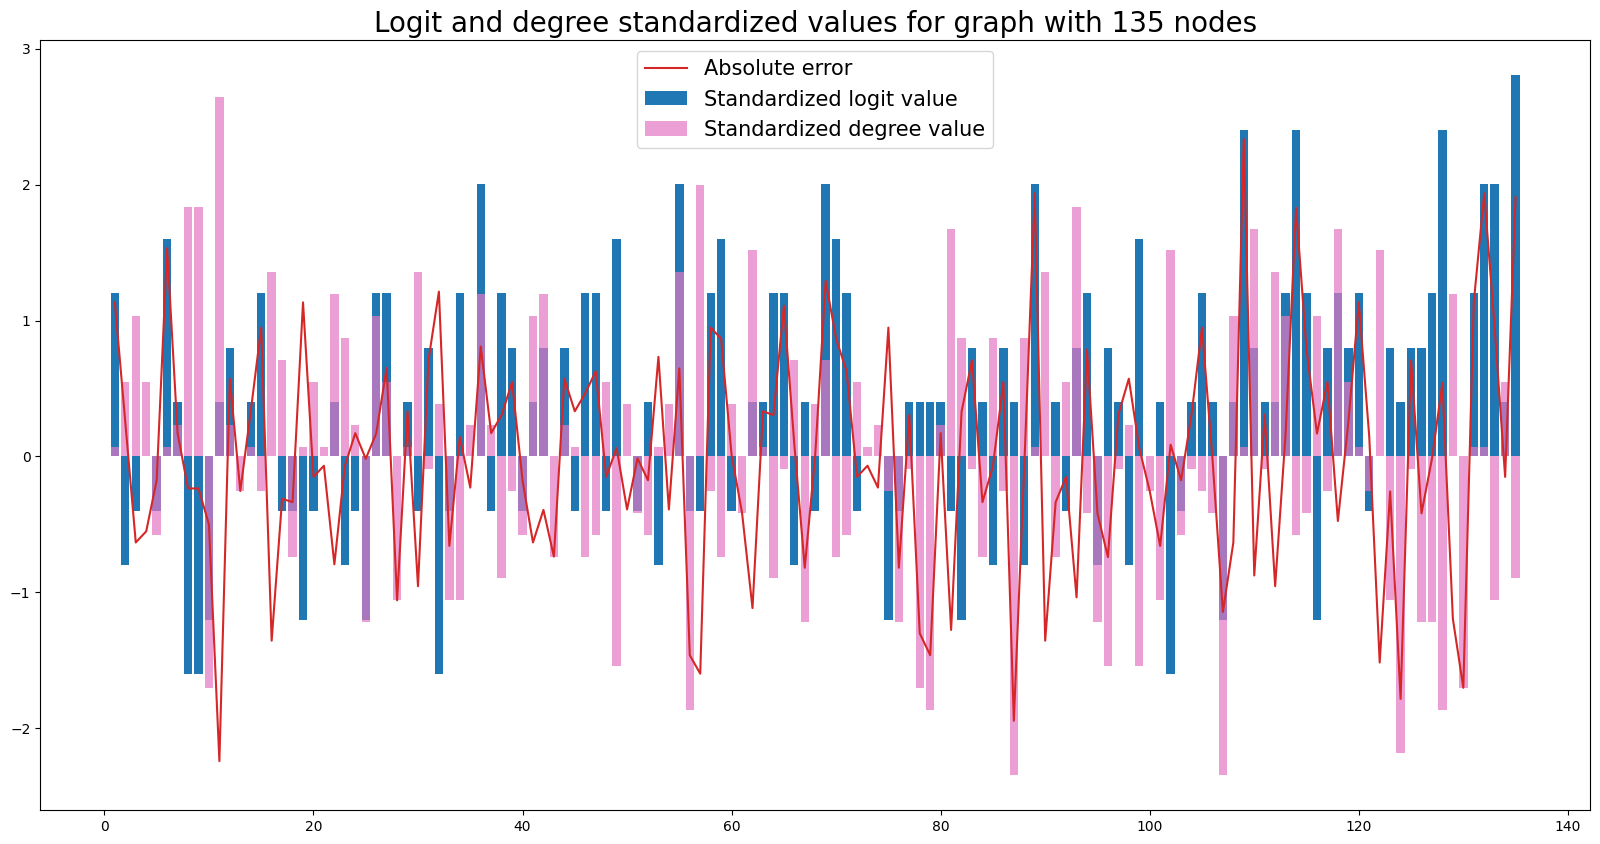

In [414]:
from torch_geometric.utils import degree
import numpy as np
import utils.graph_utils as graph_utils
import matplotlib.pyplot as plt

# make plot bigger
plt.rcParams["figure.figsize"] = (20,10)

problem = problems[5]
# problem, _ = graph_utils.load_problem('data/9')
net = PolicyNetwork(1, problem.num_nodes).to('cuda')
logit, _, _ = net(problem.cuda(), False)
logit = logit.cpu().detach()
deg = degree(problem.edge_index[1], problem.num_nodes).cpu() # vstupny stupen

#torch render 4 decimal places on print and turn of scientific notation
torch.set_printoptions(precision=4, sci_mode=False)

# normalize logit
logit = (logit - logit.mean()) / logit.std()
deg = (deg - deg.mean()) / deg.std()

abs_error = torch.abs(logit) - torch.abs(deg)

plt.bar(torch.arange(logit.shape[1]) + 1, logit[0], label='Standardized logit value', color='tab:blue')
plt.bar(torch.arange(deg.shape[0]) + 1, deg, label='Standardized degree value', alpha=0.7, color='tab:pink')
plt.plot(torch.arange(abs_error.shape[1]) + 1, abs_error[0], label='Absolute error', color='tab:red')

plt.legend(fontsize=15)

# plot title
plt.title(f'Logit and degree standardized values for graph with {problem.num_nodes} nodes', fontsize=20)

In [308]:
torch.arange(logit.shape[1]) + 1

tensor([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
         15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
         29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
         43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
         71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
         99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
        113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
        127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
        141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 1

In [14]:
graph.x

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      

In [69]:
np.save('evals/rne_results/_.npy', res)

In [21]:
import numpy as np
res = np.array(list(results.values()))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(nodes, res[:, :, 0].sum(axis=1))
plt.scatter(nodes, res[:, :, 0].sum(axis=1))
plt.xlabel('Problem size')
plt.ylabel('[%]')
plt.title('Percentage of finding optimal solution across different problem sizes with random NN')

In [19]:
res.shape

(10, 100, 3)

In [17]:
# Difference from optimal
res[:, :, 2] - np.array(optimal)[:, np.newaxis]

ValueError: operands could not be broadcast together with shapes (10,100) (11,1) 

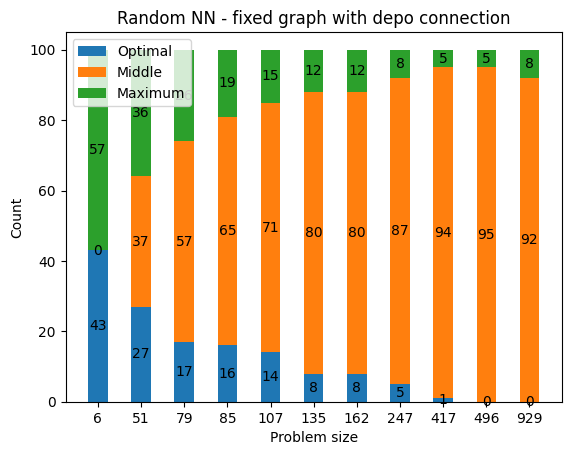

In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
bottom = np.zeros(res.shape[0])
width = 0.45

opt = (res[:, :, 1] <= 1.15).sum(axis=1)
maxi = (res[:, :, 2] == (np.array(nodes) - 2)[:, np.newaxis]).sum(axis=1)
mid = res.shape[1] - (opt + maxi)

sols = {
    'Optimal': opt,
    'Middle': mid,
    'Maximum': maxi
}

for name, count in sols.items():
    p = ax.bar(list(map(str, nodes)), count, width, label=name, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.set_title('Random NN - fixed graph with depo connection')
ax.set_ylabel('Count')
ax.set_xlabel('Problem size')
ax.legend()
plt.show()

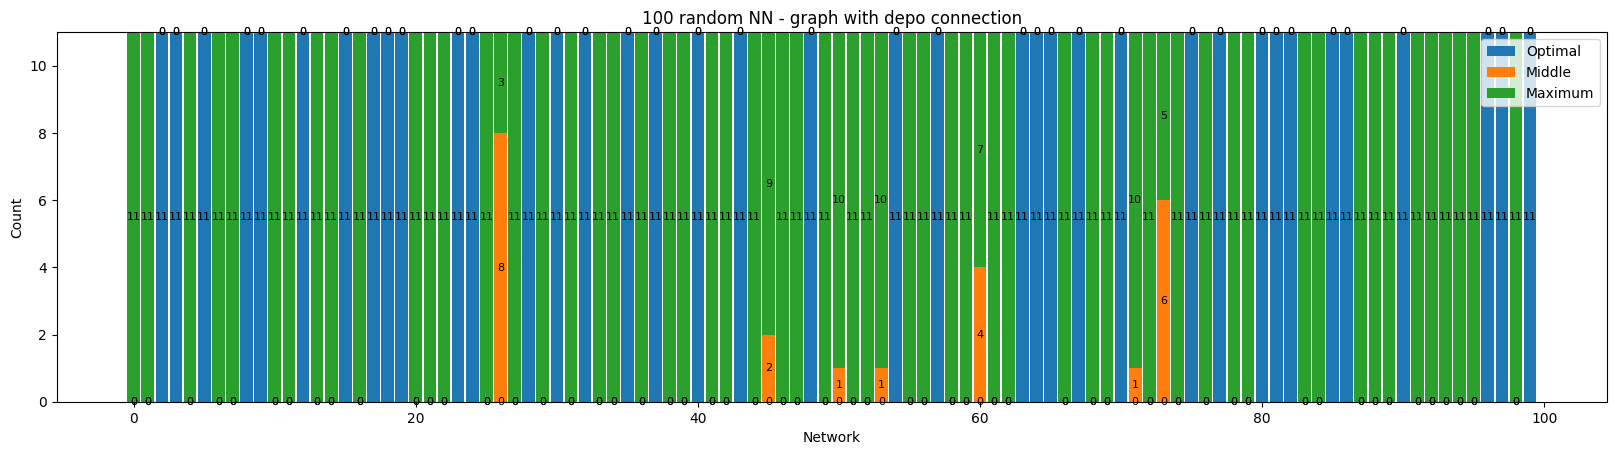

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
bottom = np.zeros(res.shape[1])
width = 0.9

#make figure wider
fig.set_figwidth(20)

opt = (res[:, :, 1] <= 1.15).sum(axis=0)
maxi = (res[:, :, 2] == (np.array(nodes) - 2)[:, np.newaxis]).sum(axis=0)
mid = res.shape[0] - opt - maxi

sols = {
    'Optimal': opt,
    'Middle': mid,
    'Maximum': maxi
}

for name, count in sols.items():
    p = ax.bar(list(range(len(bottom))), count, width, label=name, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center', size=8)

ax.set_title('100 random NN - graph with depo connection')
ax.set_ylabel('Count')
ax.set_xlabel('Network')
ax.legend()
plt.show()

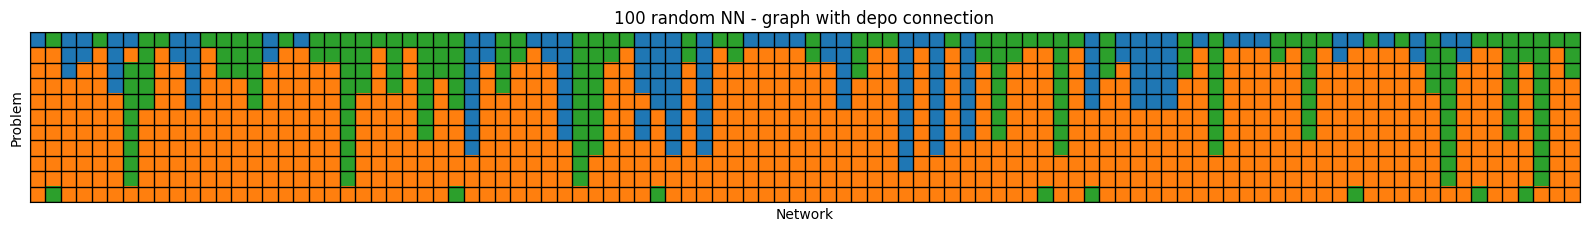

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

data = np.zeros((res.shape[0], res.shape[1])) + 1

opt = (res[:, :, 1] <= 1.15)
maxi = (res[:, :, 2] == (np.array(nodes) - 2)[:, np.newaxis])

data[opt] = 0
data[maxi] = 2

# create discrete colormap
cmap = colors.ListedColormap(['tab:blue', 'tab:orange', 'tab:green'])

fig, ax = plt.subplots()
fig.set_figwidth(20)
ax.imshow(data, cmap=cmap)

plt.grid(axis='both', color='k', linewidth=1) 
plt.xticks(np.arange(-0.5, data.shape[1], 1))
plt.yticks(np.arange(-0.5, data.shape[0], 1))

plt.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

ax.set_title(f"{data.shape[1]} random NN - graph with depo connection")
ax.set_ylabel('Problem')
ax.set_xlabel('Network')
plt.show()